### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [2]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

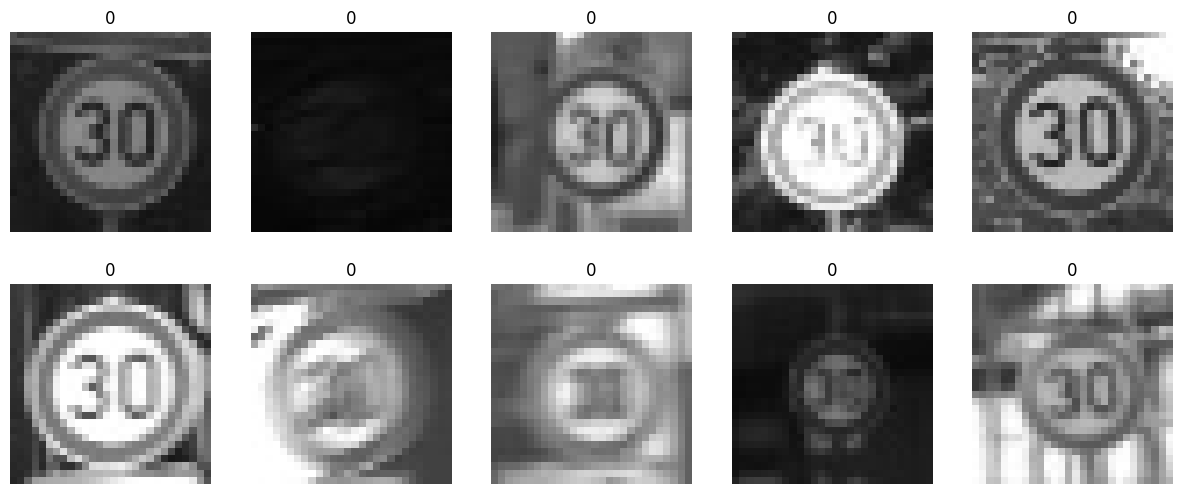

In [37]:
folder = '../../data/lesson_12/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

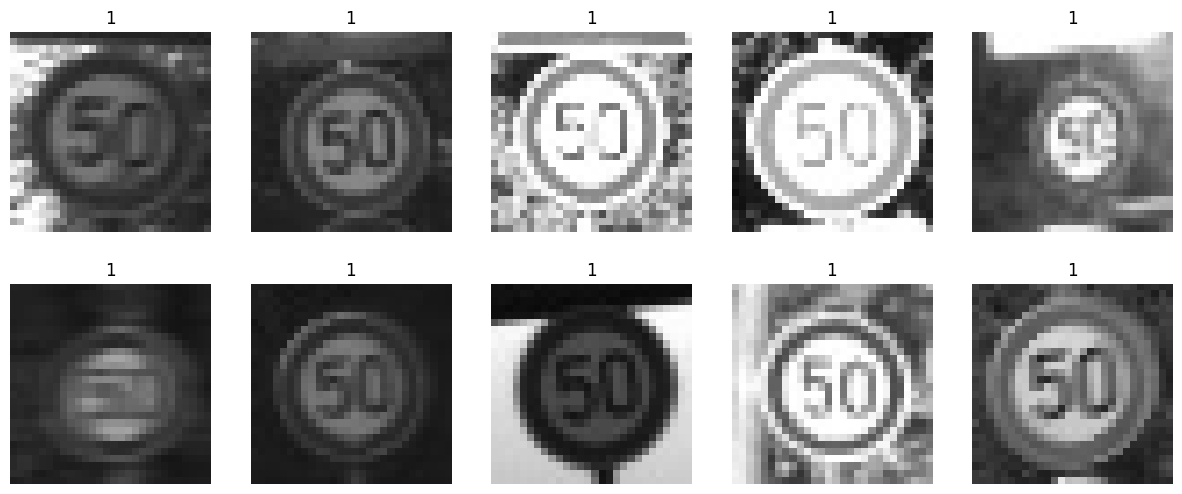

In [38]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [39]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [40]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [41]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)
    
pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.3933830261230469


Or, you know, just let make use of our friend numpy :-)

In [14]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4260, 784)
Elapsed time 0.04575681686401367


Before the training, let's again have a look at some random samples from our dataset.

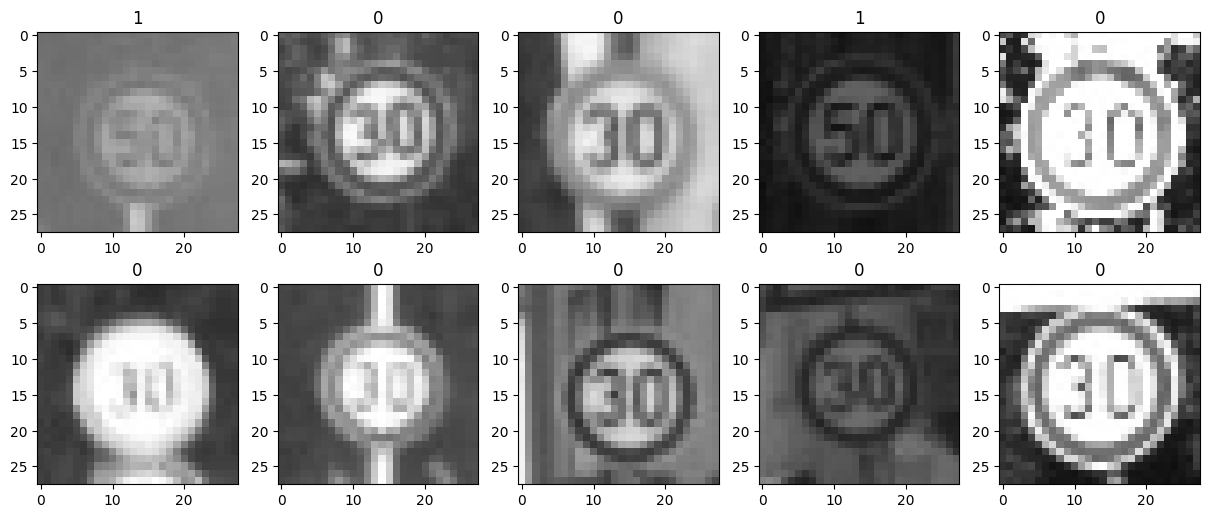

In [44]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [45]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [251]:
inputs = Input(shape=(pixels.shape[1],))
layer = Dense(128, activation="linear")(inputs)
outputs = Dense(1, activation="linear")(layer)
model = Model(inputs, outputs)

model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [252]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [253]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [254]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.7515
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 0.1698
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 0.1304
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - loss: 0.1121
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.1132
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 0.1253
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.1209
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.1326
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.1039
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 0.1423


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

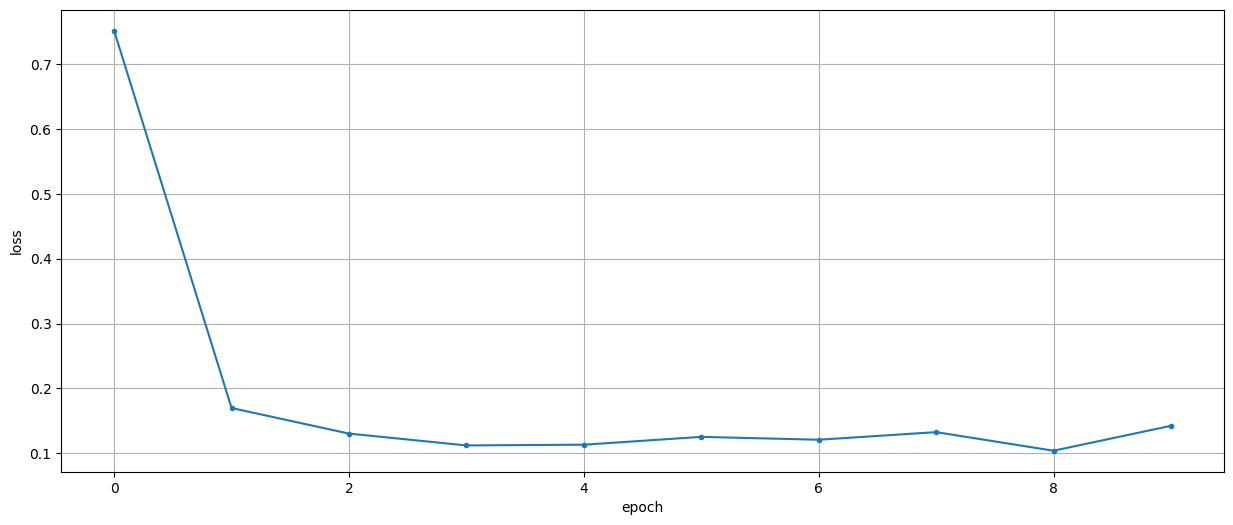

In [255]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[-0.04490796  0.04504294  0.04815487  0.04806639 -0.04554956  0.03450307
 -0.04519251 -0.04572063 -0.04606535  0.03640763  0.03683768 -0.03721582
  0.03240393 -0.04800557 -0.0330126  -0.04450598  0.04738816  0.04337189
  0.04214357 -0.04438028  0.03111966  0.03412937 -0.03908892  0.04615382
 -0.047275    0.04673535  0.04266999 -0.04703958  0.03059254 -0.04523057
 -0.04748398 -0.04543503  0.04768129 -0.04007063  0.04421198 -0.0455762
 -0.03821067  0.04613486  0.0178561  -0.14285618 -0.04707301 -0.04286001
 -0.04692483 -0.0398217  -0.04242773 -0.04250719  0.03100682  0.04652866
 -0.04241297 -0.04663505  0.04381434 -0.04753046 -0.1171268   0.04750964
 -0.03034006  0.03793019 -0.0468545   0.04185347 -0.04625168 -0.03683202
 -0.04018566 -0.04193966 -0.04626782 -0.04374291 -0.04423908  0.04278637
  0.01953686 -0.02802143  0.04301229  0.04659716  0.03978639  0.04271296
  0.04497168  0.04454847 -0.03976078  0.04487074 -0.03182063 -0.04557349
 -0.04628823  0.04432014 -0.04422735  0.04706129 -0.

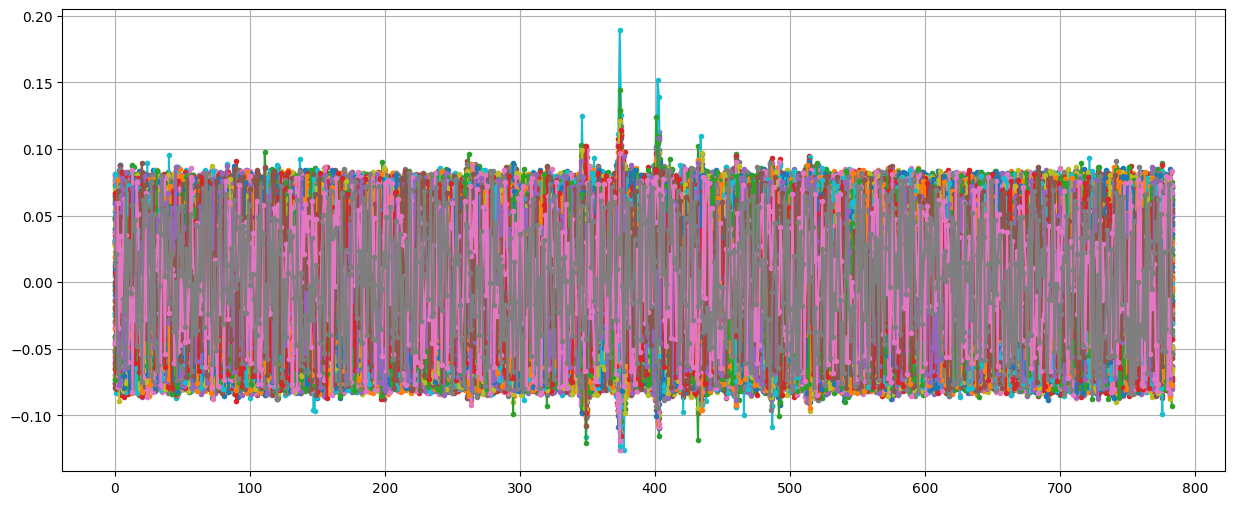

In [256]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [257]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[0.9661254]] 1


In [258]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 245us/step


In [259]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9105145413870246


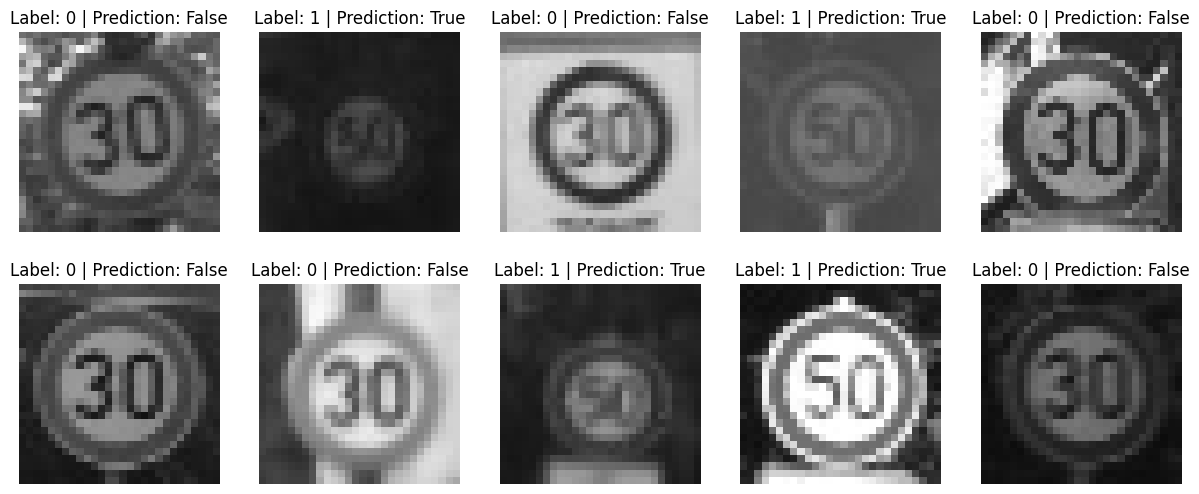

In [199]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

> 1. Запустил обучение на одном нейроне, точность 0.91, ниже чем у первого примера, думаю из-за того что в первом у нас отличалась сама форма знака еще, в домашнем примере у нас форма знака - круг, а само отличие в цифрах внутри, что при таком небольшом расширении изображения не так сильно влияет на результат. Все равно не плохо, потому что на некоторых рандомных изображениях я и сам едва могу отличить цифры внутри знаков :)

> 2. Дальше добавил еще один скрытый слой с 128 нейронами, финальный слой оставил с одним нейроном для бинарной классификации. Точность выросла до 0.92. Не так сильно, но все же, а еще судя по графику, модель стала обучаться за меньшее количество эпох, при чем намного быстрее, где-то на 5й эпохе ошибка уже не сильно менялась, иногда даже повышалась на 7й эпохе. При увеличении количества нейронов в скрытом слое до 256, точность выросла до 0.96. После увеличения количества нейронов до 512 и дальнейшее увеличение до 1024 и 2048 точность не увеличивалась, а даже немного снижалась, думаю из-за переобучения. График истории обучения становился более плоский, но особого улучшения все равно не наблюдалось. Добавление количества скрытых слоев с разным количеством нейронов не улучшало результат, а иногда даже ухудшало его. По моему, в данном случае я просто упираюсь в максимальную точность котороую может дать модель которая на вход принимает развернутый масив в вектор, вместо работы с 2D матрицей где можно зацепится за контекст соседних пикселей.

>Максимальная точность которую я смог достичь - 0.96 при увеличении количества нейронов в скрытом слое до 256. При меньшем количестве нейронов результат часто плавал и был даже меньше 89, только после нескольких запусков обучения удавалось его поднять до 91-92.